# Pose-graph SLAM: Levenberg–Marquardt on a factor graph, as one C function

A robot drives four laps of a loop, integrating wheel odometry. Odometry drifts, so the
dead-reckoned path does not close. Each time the robot sees a place it has already visited it
records a **loop closure**: a noisy measurement of its pose relative to the earlier one. Pose-graph
SLAM finds the poses $x_i = (p_i, \theta_i) \in \mathbb{R}^2 \times S^1$ that best agree with all
the relative measurements $z_{ij}$ together:

$$
\min_{x} \; \tfrac12 \sum_{(i,j) \in \mathcal{E}} \big\| \Sigma_{ij}^{-1/2}\, e(x_i, x_j, z_{ij}) \big\|^2,
\qquad
e = \begin{bmatrix} R(\theta_i)^\top (p_j - p_i) - z^{p}_{ij} \\ \operatorname{wrap}(\theta_j - \theta_i - z^{\theta}_{ij}) \end{bmatrix}.
$$

This is the nonlinear least-squares problem behind GTSAM, g2o and Ceres. Its structure fits Scaly
well:

- **Every factor is the same small function.** Written once, it is `vmap`ped over the edges, so
  the generated code has one loop body whatever the number of edges.
- **The graph is an index table.** Poses are pulled into edge order with `sc.gather`. The Jacobian
  and the normal matrix $J^\top J$ then take the pattern of the graph. Scaly works that pattern out
  once, when the graph is built.
- **The topology is fixed and the data are not.** The measurements are an input. One generated
  solver therefore serves every data set on the same graph. A fixed-lag smoother, which sees a
  window of fixed shape, is exactly this situation.

| Scaly feature | Where |
| --- | --- |
| `sc.gather` with static index tables, `sc.vmap` over edges | the stacked residual |
| `sc.sparse_jacobian` → `SparseMatrix`, sparse–sparse `J.T @ J` | the Gauss–Newton matrix, pattern found at build time |
| `linalg.analyze`, `linalg.SparseLDL` | ordering and fill of the normal equations, the factorization as generated loops |
| `sc.while_loop` with `sc.where` | Levenberg–Marquardt with accept/reject and damping updates, in C |

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy import optimize, sparse

import plotstyle
import scaly as sc
from scaly import linalg
from scaly.codegen import write_module

plotstyle.use()
GENERATED = Path.cwd().parent / "generated" / "pose_graph_slam"
rng = np.random.default_rng(3)

## A synthetic data set

The ground truth is four laps of a rounded rectangle, 60 poses per lap. Each odometry edge
$(i, i+1)$ measures the true relative pose with noise. A loop closure $(i, j)$ is added whenever
pose $j$ lies within 1 m of a pose $i$ from an earlier lap, keeping one closure per neighbourhood. Its noise is
somewhat larger.

In [2]:
LAPS, PER_LAP = 4, 60
N = LAPS * PER_LAP


def track(s):
  """A rounded rectangle, 12 m x 6 m, parametrized by s in [0, 1)."""
  phi = 2 * np.pi * s
  x = 6 * np.sign(np.cos(phi)) * np.abs(np.cos(phi)) ** 0.5
  y = 3 * np.sign(np.sin(phi)) * np.abs(np.sin(phi)) ** 0.5
  return np.stack([x, y], axis=-1)


s = np.arange(N) / PER_LAP + 0.03 * rng.standard_normal(N).cumsum() / PER_LAP
p_true = track(s % 1.0) + 0.15 * np.stack([np.sin(0.7 * np.arange(N)), np.cos(0.4 * np.arange(N))], axis=1)
heading = np.unwrap(np.arctan2(*np.gradient(p_true, axis=0).T[::-1]))
X_TRUE = np.column_stack([p_true, heading])


def relative(xi, xj):
  """The pose of j in the frame of i."""
  c, s_ = np.cos(xi[..., 2]), np.sin(xi[..., 2])
  d = xj[..., :2] - xi[..., :2]
  dth = np.angle(np.exp(1j * (xj[..., 2] - xi[..., 2])))
  return np.stack([c * d[..., 0] + s_ * d[..., 1], -s_ * d[..., 0] + c * d[..., 1], dth], axis=-1)


odometry = [(i, i + 1) for i in range(N - 1)]
closures = []
for j in range(N):
  for i in range(j - PER_LAP // 2):
    if np.linalg.norm(p_true[i] - p_true[j]) < 1.0 and not any(abs(i - a) < 8 and abs(j - b) < 8 for a, b in closures):
      closures.append((i, j))
EDGES = np.array(odometry + closures)
E = len(EDGES)
SIGMA = np.array([[0.05, 0.05, 0.02]] * len(odometry) + [[0.1, 0.1, 0.03]] * len(closures))
Z = relative(X_TRUE[EDGES[:, 0]], X_TRUE[EDGES[:, 1]]) + SIGMA * rng.standard_normal((E, 3))
print(f"{N} poses, {len(odometry)} odometry edges, {len(closures)} loop closures: {3 * N} unknowns, {3 * E + 3} residuals")

240 poses, 239 odometry edges, 60 loop closures: 720 unknowns, 900 residuals


Integrating odometry alone gives the initial guess. It drifts by metres after four laps.

In [3]:
def compose(xi, z):
  c, s_ = np.cos(xi[2]), np.sin(xi[2])
  return np.array([xi[0] + c * z[0] - s_ * z[1], xi[1] + s_ * z[0] + c * z[1], xi[2] + z[2]])


X_ODOM = [X_TRUE[0]]
for k in range(N - 1):
  X_ODOM.append(compose(X_ODOM[-1], Z[k]))
X_ODOM = np.array(X_ODOM)
print(
  f"dead-reckoning position error: mean {np.linalg.norm(X_ODOM[:, :2] - p_true, axis=1).mean():.2f} m, final {np.linalg.norm(X_ODOM[-1, :2] - p_true[-1]):.2f} m"
)

dead-reckoning position error: mean 1.31 m, final 2.03 m


## The factor, written once

`edge_residual` is one factor, weighted by its square-root information. The angle difference is
wrapped with `atan2(sin, cos)`. Its derivative is 1 wherever it is defined, so the Jacobian does
not notice the wrap.

`residual` pulls each edge's two poses into edge order with a static `gather`. It then `vmap`s the
factor over the edges with stride 3. Pose 0 is anchored by a strong prior, which fixes the gauge
freedom (a rigid motion of the whole map). The measurements `z` are an input to the graph, not
constants.

In [4]:
@sc.function(3, 3, 3, 3)
def edge_residual(xi, xj, z, w):
  c, s_ = xi[2].cos(), xi[2].sin()
  d = xj[:2] - xi[:2]
  dth = xj[2] - xi[2] - z[2]
  e = sc.stack([c * d[0] + s_ * d[1] - z[0], -s_ * d[0] + c * d[1] - z[1], sc.atan2(dth.sin(), dth.cos())])
  return w * e


IDX_I = (3 * EDGES[:, 0:1] + np.arange(3)).ravel()
IDX_J = (3 * EDGES[:, 1:2] + np.arange(3)).ravel()
W = sc.const((1.0 / SIGMA).ravel())
ANCHOR = X_ODOM[0]


def residual(x, z):
  xi, xj = sc.gather(x, IDX_I), sc.gather(x, IDX_J)
  edges = sc.vmap(edge_residual, E, [(xi, 0, 3), (xj, 0, 3), (z, 0, 3), (W, 0, 3)])
  return sc.concat([1e3 * (x[:3] - sc.const(ANCHOR)), edges])


x_s, z_s = sc.sym("x", 3 * N), sc.sym("z", 3 * E)
jac = sc.sparse_jacobian(residual(x_s, z_s), x_s)
J = linalg.SparseMatrix.from_sparse_jacobian(jac)
H = J.T @ J
print(f"J: {J.shape[0]} x {J.shape[1]}, {jac.sparsity.nnz} nonzeros; J^T J: {H.nnz} stored entries ({100 * H.nnz / (3 * N) ** 2:.2f}% dense)")

J: 900 x 720, 3591 nonzeros; J^T J: 6342 stored entries (1.22% dense)


## Structure: the graph is the matrix

$J^\top J$ has a $3 \times 3$ block at $(i, j)$ exactly when poses $i$ and $j$ share a factor. The
odometry chain gives a block tridiagonal band, and each loop closure adds an off-band block.
`linalg.analyze` chooses the fill-reducing ordering (the same choice `SparseLDL` makes). It also
gives the pattern of the factor $L$. Both are computed once, in Python, when the graph is built.

ordering    nnz(L)    fill  multiply-adds
natural      48095   45284        1989718
rcm          14771   11960         181903
mmd           6962    4151          50353


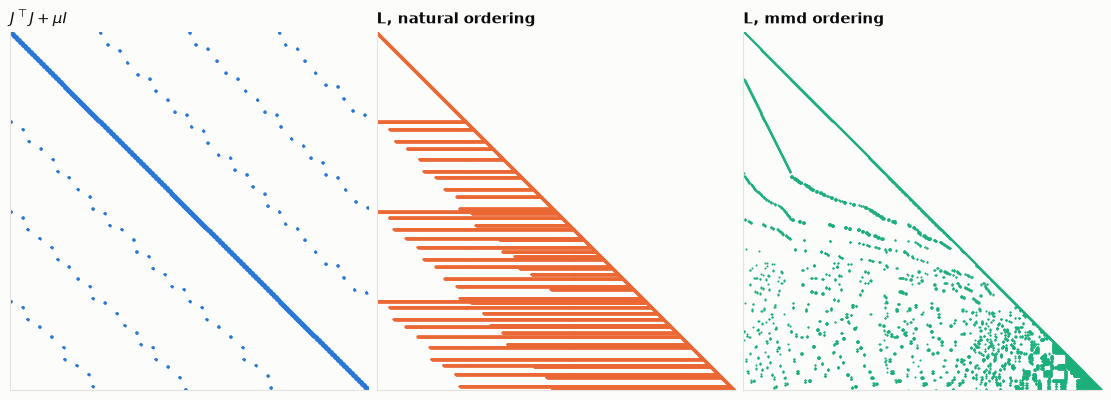

In [5]:
Hd = H.add_diagonal(sc.const(1.0))  # the damped matrix J^T J + mu I stores its diagonal
rows_h, cols_h = Hd.coordinates()
analyses = {m: linalg.analyze(Hd.shape, rows_h, cols_h, m) for m in ("natural", "rcm", "mmd")}
print(f"{'ordering':9s} {'nnz(L)':>8s} {'fill':>7s} {'multiply-adds':>14s}")
for m, a in analyses.items():
  st = a.stats()
  print(f"{m:9s} {st['nnz_l']:8d} {st['fill']:7d} {st['update_lanes']:14d}")


def factor_mask(a):
  """The pattern of L (with its diagonal) in the permuted order."""
  mask = np.eye(a.n, dtype=bool)
  for j in range(a.n):
    mask[a.l_rows[a.l_ptr[j] : a.l_ptr[j + 1]], j] = True
  return mask


fig, axes = plt.subplots(1, 3, figsize=(11, 3.9))
axes[0].spy(Hd.sparsity.to_mask(), markersize=0.5, color=plotstyle.BLUE)
axes[0].set_title(r"$J^\top J + \mu I$")
for ax, m, color in zip(axes[1:], ("natural", "mmd"), (plotstyle.ORANGE, plotstyle.AQUA)):
  ax.spy(factor_mask(analyses[m]), markersize=0.5, color=color)
  ax.set_title(f"L, {m} ordering")
for ax in axes:
  ax.grid(False)
  ax.set_xticks([])
  ax.set_yticks([])
plt.show()

In the natural order each loop closure fills in the whole band between its two poses. Minimum
degree keeps the factor several times sparser. Keeping this fill low is also what the variable
orderings in GTSAM and g2o are for.

## Levenberg–Marquardt in generated C

One iteration linearizes, solves the damped normal equations
$(J^\top J + \mu I)\,\delta = -J^\top r$ and evaluates the cost at $x + \delta$. It accepts the step
and decreases $\mu$ if the cost went down, and otherwise rejects it and increases $\mu$. Everything
the loop needs sits in one carry vector $[x, \mu, f, \lVert\delta\rVert_\infty]$. The measurements
are a loop parameter. The accept/reject decision is a `sc.where`, so the loop has no branches in
Python.

In [6]:
NX = 3 * N


def cost(x, z):
  return 0.5 * sc.sumsqr(residual(x, z))


@sc.function
def lm_step(carry, z):
  x, mu, f = carry[:NX], carry[NX], carry[NX + 1]
  r = residual(x, z)
  J = linalg.SparseMatrix.from_sparse_jacobian(sc.sparse_jacobian(r, x))
  fact = linalg.SparseLDL((J.T @ J).add_diagonal(mu), name="normal")
  delta = -fact.solve(J.T @ r)
  f_trial = cost(x + delta, z)
  better = sc.less(f_trial, f)
  x_next = sc.where(better, x + delta, x)
  mu_next = sc.where(better, sc.maximum(mu * (1.0 / 3.0), 1e-9), mu * 4.0)
  return sc.concat([x_next, sc.stack([mu_next, sc.where(better, f_trial, f), sc.norm_inf(delta)])])


@sc.function
def not_converged(carry, z):
  return sc.greater(carry[NX + 2], 1e-9)


@sc.function(NX, 3 * E, output=sc.G("x", "cost", "iterations"))
def pose_graph_solve(x0, z):
  start = sc.concat([x0, sc.stack([sc.const(1e-3), cost(x0, z), sc.const(np.inf)])])
  carry, n_iter = sc.while_loop(not_converged, lm_step, start, max_iter=100, params=(z,))
  return carry[:NX], carry[NX + 1], n_iter

`lm_step` is a `Function` in its own right, so the iteration can be driven from Python to watch it.
From dead reckoning, two steps take the cost most of the way to its minimum, which is roughly
half the number of residuals, as it should be for correctly weighted noise. The remaining
iterations shrink the step below the tolerance while the damping falls back towards Gauss–Newton.

cost per iteration: [5396.8201  108.1652   83.5195   83.515    83.515    83.515    83.515    83.515    83.515
   83.515 ]


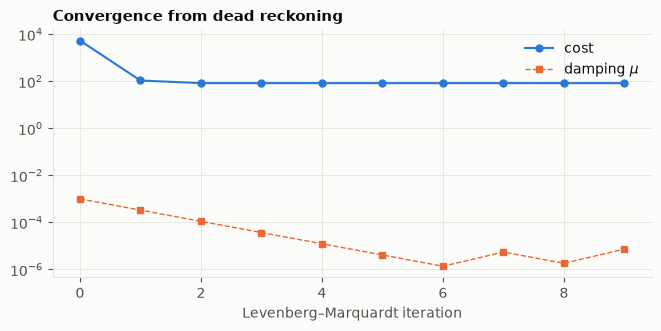

In [7]:
@sc.function(NX, 3 * E)
def residual_fn(x, z):
  return residual(x, z)


z_data = Z.ravel()
carry = np.r_[X_ODOM.ravel(), 1e-3, 0.5 * np.sum(residual_fn(X_ODOM.ravel(), z_data) ** 2), np.inf]
history = [(carry[NX + 1], carry[NX])]
for _ in range(30):
  carry = lm_step(carry, z_data)
  history.append((carry[NX + 1], carry[NX]))
  if carry[NX + 2] < 1e-9:
    break
history = np.array(history)
print("cost per iteration:", np.array2string(history[:, 0], precision=4, max_line_width=100))

fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.semilogy(history[:, 0], "o-", color=plotstyle.BLUE, lw=1.5, label="cost")
ax.semilogy(history[:, 1], "s--", color=plotstyle.ORANGE, lw=1, ms=4, label=r"damping $\mu$")
ax.set_xlabel("Levenberg–Marquardt iteration")
ax.set_title("Convergence from dead reckoning")
ax.legend()
plt.show()

## The whole solve, one call

`pose_graph_solve` runs the same loop inside C. It is checked against SciPy's
`least_squares` with MINPACK's Levenberg–Marquardt, which works with dense Jacobians. SciPy is given Scaly's residual
and its compact Jacobian, converted to a SciPy matrix, so both solvers minimize the same function.
Their optima agree to rounding.

In [8]:
x0 = X_ODOM.ravel()
x_opt, f_opt, iters = pose_graph_solve(x0, z_data)  # compiles on the first call
start = time.perf_counter()
for _ in range(20):
  x_opt, f_opt, iters = pose_graph_solve(x0, z_data)
t_scaly = (time.perf_counter() - start) / 20


@sc.function(NX, 3 * E)
def jac_fn(x, z):
  return sc.sparse_jacobian(residual(x, z), x).values


rows_j, cols_j = np.array(jac.sparsity.rows), np.array(jac.sparsity.cols)
shape_j = jac.sparsity.shape
residual_fn(x0, z_data), jac_fn(x0, z_data)  # compile both before timing
start = time.perf_counter()
ref = optimize.least_squares(
  lambda x: residual_fn(x, z_data),
  x0,
  jac=lambda x: sparse.csr_array((jac_fn(x, z_data), (rows_j, cols_j)), shape=shape_j).toarray(),
  method="lm",
  xtol=1e-14,
  ftol=1e-14,
  gtol=1e-14,
)
t_scipy = time.perf_counter() - start
print(f"Scaly LM: {int(iters)} iterations, cost {f_opt:.6f}, {1e3 * t_scaly:.1f} ms per solve")
print(f"SciPy (MINPACK LM, dense): {ref.nfev} evaluations, cost {ref.cost:.6f}, {1e3 * t_scipy:.0f} ms")
print(f"|x_scaly - x_scipy|_inf = {np.abs(x_opt - ref.x).max():.1e}")
X_OPT = x_opt.reshape(N, 3)
print(
  f"position error: mean {np.linalg.norm(X_OPT[:, :2] - p_true, axis=1).mean():.3f} m (dead reckoning: {np.linalg.norm(X_ODOM[:, :2] - p_true, axis=1).mean():.2f} m)"
)

Scaly LM: 9 iterations, cost 83.514965, 3.0 ms per solve
SciPy (MINPACK LM, dense): 7 evaluations, cost 83.514965, 1783 ms
|x_scaly - x_scipy|_inf = 1.3e-09
position error: mean 0.257 m (dead reckoning: 1.31 m)


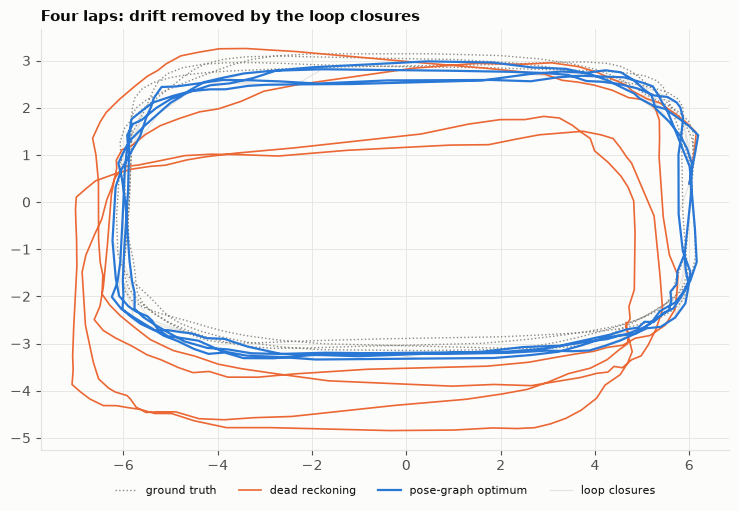

In [9]:
fig, ax = plt.subplots(figsize=(8.5, 5))
for i, j in closures:
  ax.plot(*X_OPT[[i, j], :2].T, color=plotstyle.GRID, lw=0.8, zorder=0)
ax.plot(*p_true.T, color=plotstyle.NEUTRAL, lw=1, ls=":", label="ground truth")
ax.plot(*X_ODOM[:, :2].T, color=plotstyle.ORANGE, lw=1.2, label="dead reckoning")
ax.plot(*X_OPT[:, :2].T, color=plotstyle.BLUE, lw=1.6, label="pose-graph optimum")
ax.plot([], [], color=plotstyle.GRID, lw=0.8, label="loop closures")
ax.set_aspect("equal")
ax.set_title("Four laps: drift removed by the loop closures")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.06), ncol=4, fontsize=8)
plt.show()

## One solver, many data sets

The graph fixes the topology, not the numbers. The same compiled function solves any
measurements on this graph, for example a Monte-Carlo study of the estimator. The spread of the
estimates can be compared with the covariance
$(J^\top J)^{-1}$ at the optimum. For pose $k$ that block is the Laplace approximation of its
posterior.

final pose, position error std: Monte Carlo [0.098 0.095], Laplace [0.104 0.103] m
over all poses, Monte-Carlo / Laplace std: median 0.96


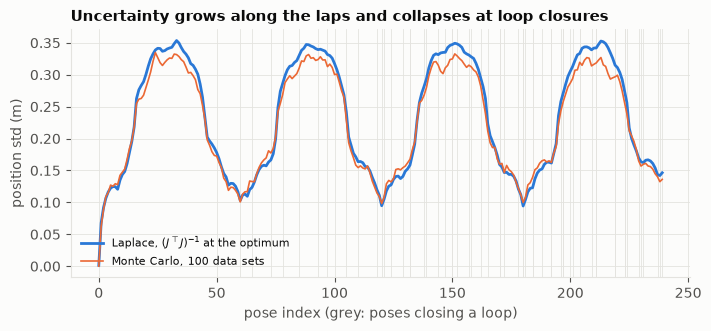

In [10]:
trials = []
for _ in range(100):
  z_mc = relative(X_TRUE[EDGES[:, 0]], X_TRUE[EDGES[:, 1]]) + SIGMA * rng.standard_normal((E, 3))
  x_init = [X_TRUE[0]]
  for k in range(N - 1):
    x_init.append(compose(x_init[-1], z_mc[k]))
  x_mc, _, _ = pose_graph_solve(np.array(x_init).ravel(), z_mc.ravel())
  trials.append(x_mc.reshape(N, 3))
trials = np.array(trials)
Jv = sparse.csc_array((jac_fn(x_opt, z_data), (rows_j, cols_j)), shape=shape_j)
cov = np.linalg.inv((Jv.T @ Jv).toarray())
k = N - 1
rms = np.sqrt(np.mean((trials[:, :, :2] - p_true) ** 2, axis=0))  # error against the truth, per pose and axis
laplace = np.sqrt(np.diag(cov)[: 3 * N].reshape(N, 3)[:, :2])
print(f"final pose, position error std: Monte Carlo {rms[k].round(3)}, Laplace {laplace[k].round(3)} m")
print(f"over all poses, Monte-Carlo / Laplace std: median {np.median(rms / laplace):.2f}")

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(np.linalg.norm(laplace, axis=1), color=plotstyle.BLUE, label=r"Laplace, $(J^\top J)^{-1}$ at the optimum")
ax.plot(np.linalg.norm(rms, axis=1), color=plotstyle.ORANGE, lw=1.2, label="Monte Carlo, 100 data sets")
for i, j in closures:
  ax.axvline(j, color=plotstyle.GRID, lw=0.6, zorder=0)
ax.set_xlabel("pose index (grey: poses closing a loop)")
ax.set_ylabel("position std (m)")
ax.set_title("Uncertainty grows along the laps and collapses at loop closures")
ax.legend(fontsize=8)
plt.show()

## The generated C

The solver is one C function with the residual, the compact Jacobian, the sparse product
$J^\top J$, the factorization loops and the LM loop. The graph's index tables and the elimination
tree are static data. It needs no library at all, so it can be embedded as it is, for example as
the back end of a fixed-lag smoother on a robot.

In [11]:
module = write_module(pose_graph_solve, GENERATED)
print(f"{module.source_name}: {len(module.source.splitlines())} lines, {len(module.source) / 1e3:.0f} kB, workspace {module.workspace_size} doubles")

pose_graph_solve.c: 595 lines, 1194 kB, workspace 68504 doubles
